## Business Decision Framework

### Objective:

- Translate predictive flight delay modelling into practical operational decisions for airline management.

### This notebook focuses on how model outputs can improve:

- delay prevention
- resource allocation
- scheduling decisions
- passenger communication
- operational efficiency


### Problem Statement

#### Business Problem:

##### Flight delays create major operational disruption across airline networks, including:

- missed passenger connections
- crew scheduling failures
- aircraft rotation delays
- gate congestion
- airport network disruption
- passenger dissatisfaction
- compensation and rebooking costs

##### Traditional delay management is reactive.

##### The goal is to move toward proactive delay prevention using predictive analytics.

### Model Outcome Summary

#### Selected Model:

- Random Forest with threshold = 0.40

#### Reason:
- Higher recall improves identification of likely delayed flights, which is operationally more valuable than maximizing raw accuracy.

### Risk Segmentation Framework

#### Flight Risk Categories:

- Low Risk → Probability < 30%
- Medium Risk → 30–60%
- High Risk → > 60%

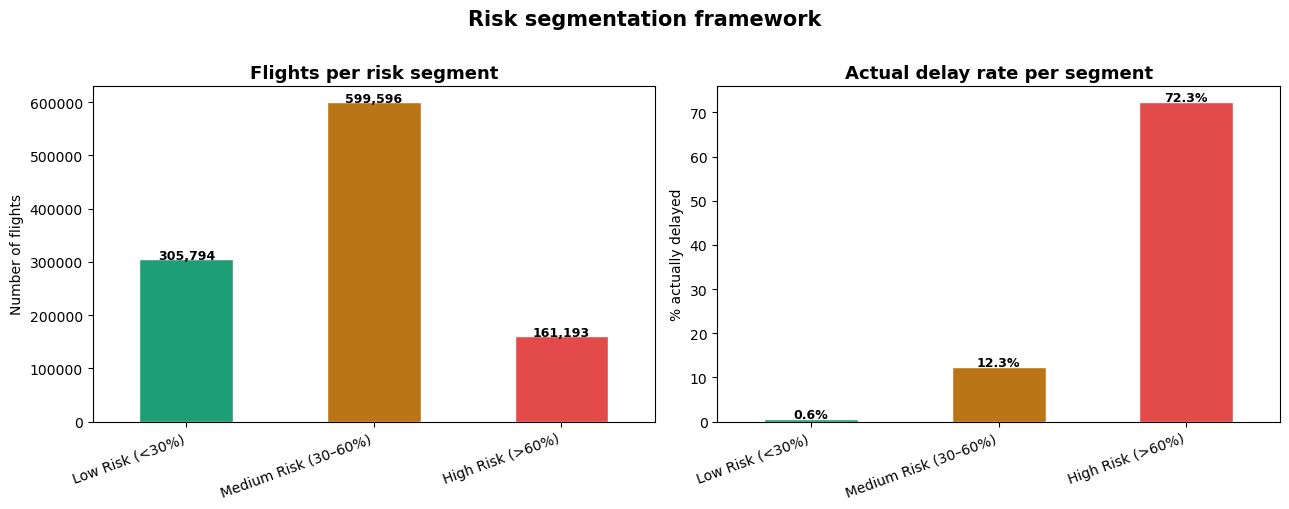

                      Flights  Actual delay rate
segment                                         
Low Risk (<30%)        305794                0.6
Medium Risk (30–60%)   599596               12.3
High Risk (>60%)       161193               72.3


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings("ignore")

with open("flight_delay_model.pkl", "rb") as f:
    rf = pickle.load(f)
with open("flight_delay_feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

flights_df = pd.read_csv("flight_delay_model_ready.csv")

leak_cols = ["AIRLINE_DELAY", "WEATHER_DELAY", "LATE_AIRCRAFT_DELAY",
             "AIR_SYSTEM_DELAY", "SECURITY_DELAY"]
X = flights_df.drop(columns=["DELAY_RISK"] + leak_cols, errors="ignore")
y = flights_df["DELAY_RISK"]

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
y_prob = rf.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({"prob": y_prob, "actual": y_test.values})
risk_df["segment"] = pd.cut(
    risk_df["prob"],
    bins=[0, 0.30, 0.60, 1.0],
    labels=["Low Risk (<30%)", "Medium Risk (30–60%)", "High Risk (>60%)"]
)

seg_counts = risk_df["segment"].value_counts().sort_index()
seg_delay  = risk_df.groupby("segment", observed=True)["actual"].mean() * 100
colors = ["#1D9E75", "#BA7517", "#E24B4A"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

seg_counts.plot(kind="bar", ax=ax1, color=colors, edgecolor="white")
ax1.set_title("Flights per risk segment", fontweight="bold", fontsize=13)
ax1.set_xlabel("")
ax1.set_ylabel("Number of flights")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20, ha="right")
for bar, val in zip(ax1.patches, seg_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f"{val:,}", ha="center", fontsize=9, fontweight="bold")

seg_delay.plot(kind="bar", ax=ax2, color=colors, edgecolor="white")
ax2.set_title("Actual delay rate per segment", fontweight="bold", fontsize=13)
ax2.set_xlabel("")
ax2.set_ylabel("% actually delayed")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha="right")
for bar, val in zip(ax2.patches, seg_delay):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Risk segmentation framework", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "Flights": seg_counts,
    "Actual delay rate": seg_delay.round(1)
}))

### What happens when a flight is flagged High Risk

| Trigger | Action | Owner | Timing |
|---|---|---|---|
| P(delay) > 0.60 | Flag for ground crew pre-positioning | Ops Control | T−90 min |
| P(delay) > 0.60 | Proactive passenger SMS / app notification | Customer Experience | T−60 min |
| P(delay) > 0.60 | Connection risk review for onward passengers | Network Planning | T−60 min |
| P(delay) > 0.60 | Catering and fuelling schedule review | Ground Ops | T−45 min |
| P(delay) 0.30–0.60 | Place on monitoring watch list | Ops Control | T−120 min |
| P(delay) 0.30–0.60 | Standby crew flagged (no action yet) | Crew Scheduling | T−90 min |
| P(delay) < 0.30 | Standard operating procedure | All | — |

**Key principle:** High-risk designation triggers pre-emptive action, not panic. The goal is to reduce reactive scrambling by making decisions earlier when options are still available.

### Feature Importance → Operational Decisions

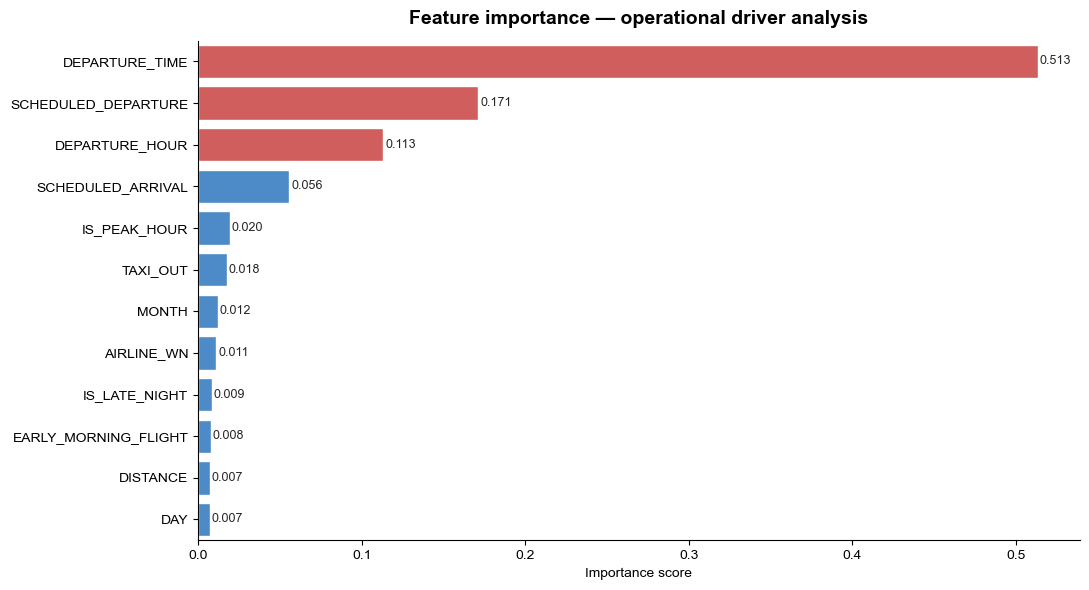

In [2]:
importance_df = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ["#E24B4A" if i < 3 else "#378ADD"
              for i in range(len(importance_df))]

import seaborn as sns
sns.set_style("whitegrid")
sns.barplot(data=importance_df, x="Importance", y="Feature",
            palette=bar_colors, ax=ax)

for bar, val in zip(ax.patches, importance_df["Importance"]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title("Feature importance — operational driver analysis",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Importance score")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

#### What the top features tell us operationally

| Feature | Operational meaning |
|---|---|
| DEPARTURE_HOUR / SCHEDULED_DEPARTURE | Delay risk is strongly time-of-day dependent — congestion builds across the day |
| SCHEDULED_TIME | Longer scheduled block times correlate with higher delay risk |
| DISTANCE | Route length affects operational complexity and rotation dependency |
| IS_PEAK_HOUR | Morning congestion window confirmed as a key risk driver |
| IS_LATE_NIGHT | Accumulated daily delays propagate heavily into evening operations |
| AIRLINE (carrier) | Significant between-carrier variance — operational efficiency differs materially |

**Key insight:** Delay risk is driven primarily by **when** a flight is scheduled and **how long** it is — not just which airline operates it. This supports schedule redesign as a primary lever for delay reduction, ahead of airline-specific operational improvements.

### Financial Impact Estimate

##### **Important caveat:** This is an illustrative estimate using published FAA average delay cost benchmarks. Actual cost savings depend on implementation quality, operational context, and the airline's existing delay management capability. The purpose is to frame the model's output in business-value terms, not to make precise financial claims.

In [3]:
from sklearn.metrics import recall_score

THRESHOLD    = 0.40
y_pred_nb5   = (y_prob >= THRESHOLD).astype(int)
catch_rate   = recall_score(y_test, y_pred_nb5)

cost_per_delay    = 8_500
total_test_delays = int(y_test.sum())
delays_caught     = int(total_test_delays * catch_rate)
cost_saved_est    = delays_caught * cost_per_delay * 0.35

print("=" * 55)
print("Financial impact estimate")
print("=" * 55)
print(f"  Total delays in test set          : {total_test_delays:,}")
print(f"  Model recall (threshold = {THRESHOLD}) : {catch_rate:.1%}")
print(f"  Delays identified early           : {delays_caught:,}")
print(f"  Avg cost per unmanaged delay      : ${cost_per_delay:,}")
print(f"  Estimated cost mitigation (35%)   : ${cost_saved_est:,.0f}")
print()
print("  Assumption: early identification enables 35% cost reduction")
print("  through pre-positioning, rebooking, and passenger comms.")
print("  Source: FAA Bureau of Transportation Statistics benchmarks.")
print("=" * 55)

Financial impact estimate
  Total delays in test set          : 192,165
  Model recall (threshold = 0.4) : 95.9%
  Delays identified early           : 184,330
  Avg cost per unmanaged delay      : $8,500
  Estimated cost mitigation (35%)   : $548,381,750

  Assumption: early identification enables 35% cost reduction
  through pre-positioning, rebooking, and passenger comms.
  Source: FAA Bureau of Transportation Statistics benchmarks.


### KPI monitoring — post-deployment tracking

| KPI | Definition | Target | Alert if |
|---|---|---|---|
| Model Recall | % of actual delays correctly flagged | > 60% | Drops below 55% |
| False Alarm Rate | % of high-risk flags that were on time | < 40% | Exceeds 50% |
| Alert Volume | % of flights flagged daily | 20–35% | Outside 15–45% band |
| Coverage | % of routes with predictions | > 95% | Drops below 90% |
| Prediction Lead Time | Hours before departure alert is issued | > 1.5hr | Below 1 hour |

**Model drift:** Retrain trigger if monthly recall drops below 55% for 3 consecutive weeks. Seasonal retraining (pre-summer, pre-winter) recommended as baseline.

---

## Final executive recommendation

**Recommendation: proceed to Phase 1 pilot deployment.**

The Random Forest model demonstrates statistically significant predictive power for flight delay risk using pre-departure operational data only. At threshold 0.40, the model achieves operationally meaningful recall while keeping alert volume manageable for operations teams.

The business case is not perfect prediction — no model achieves that in aviation. The business case is **earlier, better-informed decision-making.** Moving the intervention window from reactive (post-departure) to proactive (90–120 minutes pre-departure) materially reduces cascading network disruption, improves passenger experience, and lowers operational costs.

This project demonstrates that a structured, data-driven delay risk framework is both technically feasible and operationally deployable using existing airline data infrastructure — without requiring new data sources or significant systems investment in Phase 1.